# Programmation Orientée Objet et Hooks

In [ ]:
# https://docs.python.org/3/library/collections.abc.html
from collections.abc import Sized, Collection, Iterable, Sequence

import numpy as np
import matplotlib.pyplot as plt

from geometry import Polygon

## Builtins repr, str

In [ ]:
data = np.random.normal(10.0, 2.5, 1_000_000)
print(data) # calls str()
data # calls repr()

[ 7.846882    8.60465197  8.63359924 ... 11.32612783 10.79713353
  7.36478257]


array([ 7.846882  ,  8.60465197,  8.63359924, ..., 11.32612783,
       10.79713353,  7.36478257], shape=(1000000,))

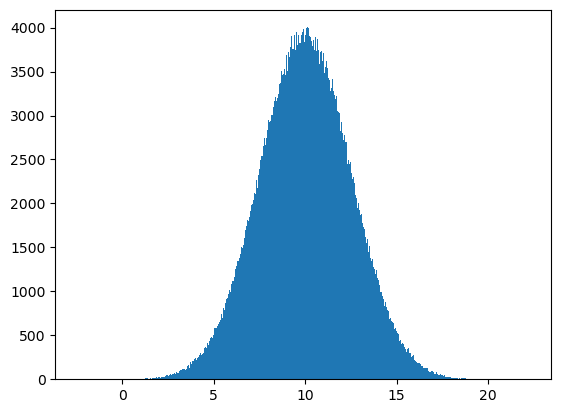

In [3]:
_ = plt.hist(data, bins=1_000)

In [4]:
data

array([ 7.846882  ,  8.60465197,  8.63359924, ..., 11.32612783,
       10.79713353,  7.36478257], shape=(1000000,))

## Builtin len
Implemented by `__len__`

In [15]:
city_name = 'Toulouse'
cities = ['Toulouse', 'Bordeaux', 'Narbonne', 'Pau']
number = 123
triangle = Polygon([
    (12.5, 7.25), 
    (12.5, 10.25), 
    (16.5, 7.25)
])

In [6]:
print(len(data)) # calls ndarray.__len__
print(len(city_name)) # calls str.__len__
# print(len(number)) # TypeError: object of type 'int' has no len()
print(len(triangle))

1000000
8
3


## Classes abstraites collections.abc

In [13]:
assert hasattr(triangle, '__len__')

assert isinstance(triangle, Sized)
for obj in city_name, data, triangle:
    assert isinstance(obj, Sized)

assert not isinstance(number, Sized)

In [ ]:


assert isinstance(cities, object)
assert isinstance(cities, list)
assert isinstance(cities, Sized)
assert isinstance(cities, Sequence)
assert isinstance(cities, Collection)
assert isinstance(cities, Iterable)

In [25]:
print(len(cities))
print(cities[0], cities[-1])
print('Toulouse' in cities)
for city in cities:
    print(city)

4
Toulouse Pau
True
Toulouse
Bordeaux
Narbonne
Pau


In [27]:
assert isinstance(city_name, Sequence)
assert not isinstance({'a': 1}, Sequence)
assert not isinstance({1, 2, 3}, Sequence)

# Iterable / Iterator

In [32]:
# str is Iterable => calls iter() => str.__iter__()
for letter in city_name:
    print(letter, end=' ')

T o u l o u s e 

In [ ]:
for city in cities: # calls list.__iter()
    print(city)

Toulouse
Bordeaux
Narbonne
Pau


In [38]:
numbers = {12, 34, 26, 18}
numbers.add(18)
numbers.add(25)
assert 18 in numbers
assert 7 not in numbers
assert not isinstance(numbers, Sequence)
assert isinstance(numbers, Iterable)
for nb in numbers: # calls set.__iter__()
    print(nb)

34
12
18
25
26


In [39]:
city_d = {
    'name': 'Toulouse',
    'population': 500_000,
    'dept': '31'
}
city_d

{'name': 'Toulouse', 'population': 500000, 'dept': '31'}

In [ ]:
# dict iteration => keys
for info_name in city_d:
    print(info_name)

name
population
dept


In [42]:
for info_name in city_d.keys():
    print(info_name)

name
population
dept


In [43]:
for info_value in city_d.values():
    print(info_value)

Toulouse
500000
31


In [47]:
for info_name, info_value in city_d.items():
    print(info_name, info_value, sep=' = ')

name = Toulouse
population = 500000
dept = 31


In [50]:
it = iter(cities)
it

In [51]:
next(it)

'Toulouse'

In [55]:
next(it)

StopIteration: 

In [56]:
it = iter([])
it

In [57]:
next(it)

StopIteration: 

In [58]:
it = iter(cities)
while True:
    try:
        city = next(it)
        print(city)
    except StopIteration:
        break

Toulouse
Bordeaux
Narbonne
Pau


In [59]:
it = iter(cities)
try:
    while True:
        city = next(it)
        print(city)
except StopIteration:
    pass

Toulouse
Bordeaux
Narbonne
Pau


### Different ways to Iterate

#### for loop

In [60]:
for city in cities:
    print(city)

Toulouse
Bordeaux
Narbonne
Pau


#### builtin with iterable arg

In [ ]:
for i, city in enumerate(cities, start=1):
    print(f"- {i} - {city}")

- 1 - Toulouse
- 2 - Bordeaux
- 3 - Narbonne
- 4 - Pau


In [63]:
it = enumerate(cities, start=1)
next(it)

(1, 'Toulouse')

In [ ]:
list
zip
sorted
reversed

reversed

In [82]:
zip(range(10), cities, 'abcdefghijklmnopqrstuvwxyz')

In [80]:
print(list(numbers))
print(list(zip(range(10), cities, 'abcdefghijklmnopqrstuvwxyz')))
print(sorted(numbers))
print(list(reversed(sorted(numbers))))
print(sorted(numbers, reverse=True))

[34, 12, 18, 25, 26]
[(0, 'Toulouse', 'a'), (1, 'Bordeaux', 'b'), (2, 'Narbonne', 'c'), (3, 'Pau', 'd')]
[12, 18, 25, 26, 34]
[34, 26, 25, 18, 12]
[34, 26, 25, 18, 12]


In [81]:
cities.count('Pau')

1

In [ ]:
# list is Iterable + Reversible
for city in reversed(cities):
    print(city)

Pau
Narbonne
Bordeaux
Toulouse


In [72]:
# reversed(numbers) # TypeError: 'set' object is not reversible

In [67]:
it = iter(range(5, 10, 2))
print(next(it))
print(next(it))

5
7


In [83]:
for n, city, l in zip(range(10), cities, 'abcdefghijklmnopqrstuvwxyz'):
    print(n, city, l)

0 Toulouse a
1 Bordeaux b
2 Narbonne c
3 Pau d


In [86]:
it = zip(range(10), cities, 'abcdefghijklmnopqrstuvwxyz')
# it2 = iter(it)
it2 = iter(iter(iter(iter(iter(it)))))
assert it is it2
it, it2

(<zip at 0x1ea13149c00>, <zip at 0x1ea13149c00>)

In [87]:
list(zip(zip(range(10), 'abc'), zip(range(10, 20), 'def')))

[((0, 'a'), (10, 'd')), ((1, 'b'), (11, 'e')), ((2, 'c'), (12, 'f'))]

In [88]:
# parcourir les villes à partir de la 2e en les numerotant sans passer par les slices
# on doit pouvoir faire à l'identique sur un ensemble
it = iter(cities)
next(it)
for city in it:
    print(city)

Bordeaux
Narbonne
Pau


In [89]:
def skip(iterable, n):
    pass

In [ ]:
for city in skip(cities, 2):
    print(city)

for x in skip([], 10_000):
    print(x)

list(skip(cities, 2))

TypeError: 'NoneType' object is not iterable